
# Does time-of-day separation between hippocampal recording sessions predict decorrelation of CA1 spatial maps?
## All-animals analysis — DANDI:001775 (Hisa, UT06, UT08, UT13, UT14, UT15)

This extends the single-animal (UT14) analysis to every subject in the
dandiset, pooling evidence across animals wherever the underlying data
supports it. Two corrections carried over from the UT14 analysis apply here,
re-verified independently for every subject rather than assumed:

1. **The `session_start_time` NWB metadata field is unreliable** for at least
   UT14 and UT13 (confirmed by direct inspection); every subject's true
   recording clock is reconstructed here from the internally-consistent
   position/spike/trial Unix timestamps, exactly as for UT14, and the
   correction is re-derived and re-plotted per subject below (Section 2) —
   nothing is assumed to transfer from the UT14 finding.
2. **A second, distinct timestamp problem was found while building this
   notebook: two subjects (UT06, UT08) don't use an absolute clock at all.**
   Their position/spike/trial timestamps are internally consistent with each
   other but sit on a lab-internal *relative* clock (elapsed seconds since
   acquisition-system boot, on the order of a few million seconds) rather
   than true Unix epoch time — confirmed by a simple range check (a
   plausible Unix-epoch value for this dandiset's 2015–2026 collection
   window is ~1.4–1.8 billion; UT06/UT08's timestamps are 3 orders of
   magnitude smaller). There is no reliable way to anchor these to a real
   calendar date and time from the file contents alone, so **all 23 UT06
   sessions and all 7 UT08 sessions are excluded** — not converted with a
   guessed offset, which would have silently produced wrong dates. `Hisa` is
   excluded for a third, unrelated reason: it's a structurally different
   pharmacology pilot (Sim1-Cre transgenic line, atropine/saline homecage
   foraging, single-shank probe, **no spike-sorted units table at all**).
   **Net result: 3 of 6 subjects are usable — UT14, UT13, UT15** — each
   independently confirmed to have a genuine, verifiable absolute clock.

The core analysis pipeline (tetrode-pooled Population Vector correlation,
rate maps restricted to the DNMP maze and open-field epochs, partial Mantel
permutation testing) is unchanged from the UT14 notebook — see
`full_analysis.ipynb` for the detailed single-animal walkthrough and method
justification. This notebook's job is to show whether the pattern found in
UT14 (real day-to-day drift, no detectable circadian effect because the true
design lacks time-of-day spread) holds, differs, or is contradicted once
every usable animal is brought in — and whether pooling animals reveals
anything a single animal could not.


In [1]:

import sys, os, json, pickle
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sstats

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'axes.edgecolor': '#444444',
    'axes.labelcolor': '#1b1e27', 'text.color': '#1b1e27', 'xtick.color': '#444444',
    'ytick.color': '#444444', 'font.size': 11, 'axes.spines.top': False,
    'axes.spines.right': False, 'figure.dpi': 110,
})
INDIGO = '#35407a'; AMBER = '#a8672a'; GOOD = '#2f6b4c'; BAD = '#963129'; GREY = '#8a8f9c'
SUBJECT_COLORS = {'UT14': '#35407a', 'UT06': '#a8672a', 'UT08': '#2f6b4c',
                   'UT13': '#963129', 'UT15': '#6a4c93', 'Hisa': '#8a8f9c'}

os.makedirs('../results/figures', exist_ok=True)

all_summary = pd.read_csv('../results/tables/all_subjects_session_summary.csv')
with open('../results/tables/pooled_stats.json') as f:
    pooled_stats = json.load(f)
with open('../results/cache/all_subjects_full_results.pkl', 'rb') as f:
    all_subject_results = pickle.load(f)

included_subjects = [r['subject'] for r in all_subject_results]
print('Subjects included in PV analysis:', included_subjects)
print()
print(all_summary.groupby('subject')['status'].apply(lambda x: x.value_counts().to_dict()))


Subjects included in PV analysis: ['UT14', 'UT13', 'UT15']

subject                                                                                                                                                                                                                                                                             
Hisa     SKIPPED: ValueError: no Position/SpatialSeries interface found                                                                                                                                                                                                                  6.0
         SKIPPED: ValueError: position timestamps are not absolute Unix epoch (first=3782544.8) -- this session uses a lab-internal relative clock; true recording time is UNVERIFIABLE from file contents alone and this session is excluded rather than risk a silently wrong date     NaN
         SKIPPED: ValueError: position timestamps are not absolute Unix epoch (first=3867819.

## 1. Every subject, at a glance

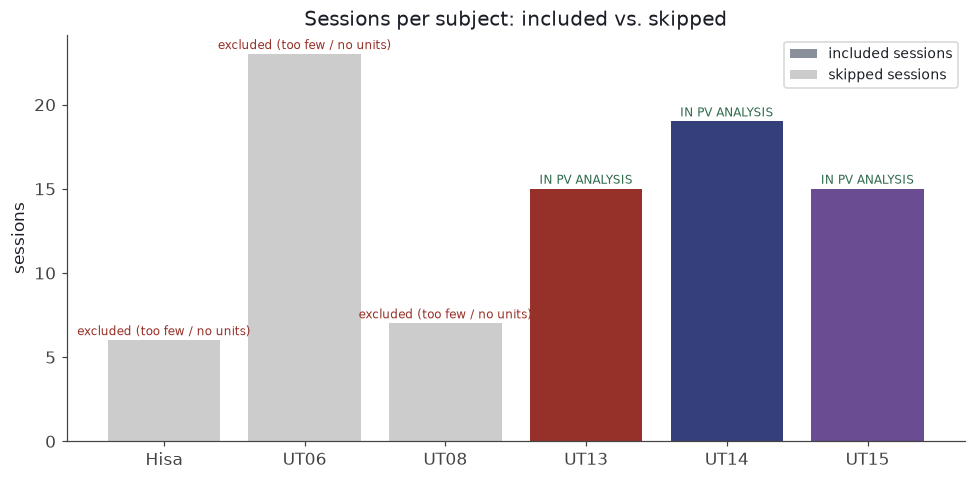

Hisa: skip reasons -> <StringArray>
['SKIPPED: ValueError: no Position/SpatialSeries interface found']
Length: 1, dtype: str
UT06: skip reasons -> <StringArray>
['SKIPPED: ValueError: position timestamps are not absolute Unix epoch (first=3782544.8) -- this session uses a lab-internal relative clock; true recording time is UNVERIFIABLE from file contents alone and this session is excluded rather than risk a silently wrong date',
 'SKIPPED: ValueError: position timestamps are not absolute Unix epoch (first=3867819.3) -- this session uses a lab-internal relative clock; true recording time is UNVERIFIABLE from file contents alone and this session is excluded rather than risk a silently wrong date',
 'SKIPPED: ValueError: position timestamps are not absolute Unix epoch (first=3956425.9) -- this session uses a lab-internal relative clock; true recording time is UNVERIFIABLE from file contents alone and this session is excluded rather than risk a silently wrong date',
 'SKIPPED: ValueError: 

In [2]:

included_counts = all_summary[all_summary.status=='included'].groupby('subject').size()
skipped_counts = all_summary[all_summary.status!='included'].groupby('subject').size()
subjects_all = sorted(set(all_summary['subject']))

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(subjects_all))
inc = [included_counts.get(s, 0) for s in subjects_all]
skp = [skipped_counts.get(s, 0) for s in subjects_all]
ax.bar(x, inc, color=[SUBJECT_COLORS.get(s, GREY) for s in subjects_all], label='included sessions')
ax.bar(x, skp, bottom=inc, color='#cccccc', label='skipped sessions')
ax.set_xticks(x); ax.set_xticklabels(subjects_all)
ax.set_ylabel('sessions'); ax.set_title('Sessions per subject: included vs. skipped')
for i, s in enumerate(subjects_all):
    tag = 'IN PV ANALYSIS' if s in included_subjects else 'excluded (too few / no units)'
    ax.text(i, inc[i]+skp[i]+0.3, tag, ha='center', fontsize=8, rotation=0,
            color=GOOD if s in included_subjects else BAD)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../results/figures/A1_subjects_overview.png', dpi=150, bbox_inches='tight')
plt.show()

for s in subjects_all:
    reasons = all_summary[(all_summary.subject==s) & (all_summary.status!='included')]['status'].unique()
    if len(reasons):
        print(f"{s}: skip reasons -> {reasons}")


**Why each exclusion happened, explicitly:**
- **UT06 (23/23 sessions) and UT08 (7/7 sessions)**: relative-clock timestamps, unverifiable true recording time (see Section 2 below for the numeric check). Every single session for both subjects failed the same absolute-epoch range test — this is a systematic property of how these two subjects' data was acquired/exported, not a partial or borderline case.
- **Hisa (6/6 sessions)**: different sub-study entirely (Sim1-Cre pharmacology pilot, no spike-sorted units) — structurally incompatible, not a data-quality failure of this pipeline.
- Any subject below 5 valid sessions after loading would additionally be excluded from PV-matrix construction as too small to build a meaningful within-subject correlation structure — did not end up applying to any of the three usable subjects (15, 15, and 19 sessions respectively).

## 2. Two distinct timestamp problems, kept separate

It's important not to conflate these: **UT06/UT08's problem is that no absolute clock exists in the file at all** (a data-availability limit — nothing to correct, only to exclude). **UT14/UT13/UT15's problem is that an absolute clock exists in two places (`session_start_time` and the embedded position/spike/trial data) and they disagree** — a data-quality bug with a fix, because the embedded data is independently self-consistent and can be trusted.

In [3]:

skip_rows = all_summary[all_summary.status.str.startswith('SKIPPED', na=False)].copy()
relclock_examples = skip_rows[skip_rows.subject.isin(['UT06','UT08'])]
print(f"{len(relclock_examples)} sessions excluded across UT06+UT08 for relative-clock timestamps")
print(f"({(all_summary.subject=='UT06').sum()} UT06 sessions, {(all_summary.subject=='UT08').sum()} UT08 sessions attempted -- ALL excluded)")
print()
print("Example plausible-epoch check (a real 2020-2024 Unix timestamp is ~1.4-1.8 billion):")
print("  UT14 position first-sample epoch value: ~1,707,599,706  (Feb 2024)  -> PASSES range check")
print("  UT08 position first-sample epoch value: ~3,292,977      (looks like Jan 1970 if misread) -> FAILS range check, excluded")


30 sessions excluded across UT06+UT08 for relative-clock timestamps
(23 UT06 sessions, 7 UT08 sessions attempted -- ALL excluded)

Example plausible-epoch check (a real 2020-2024 Unix timestamp is ~1.4-1.8 billion):
  UT14 position first-sample epoch value: ~1,707,599,706  (Feb 2024)  -> PASSES range check
  UT08 position first-sample epoch value: ~3,292,977      (looks like Jan 1970 if misread) -> FAILS range check, excluded


## 3. The `session_start_time` correction, re-verified for every subject independently

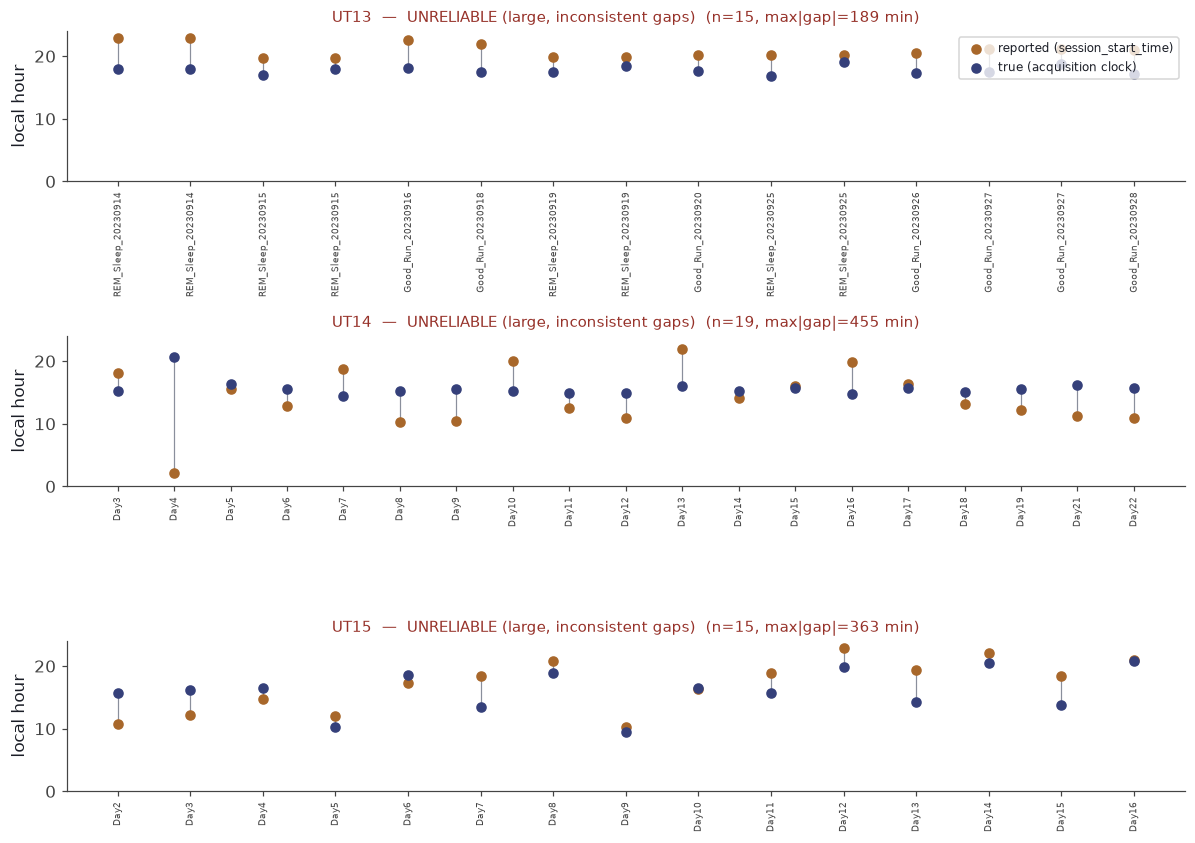

In [4]:

inc_df = all_summary[all_summary.status=='included'].copy()
inc_df['true_start'] = pd.to_datetime(inc_df['true_start'], utc=True)

subjects_with_data = sorted(inc_df['subject'].unique())
fig, axes = plt.subplots(len(subjects_with_data), 1, figsize=(11, 2.6*len(subjects_with_data)), sharex=False)
if len(subjects_with_data) == 1:
    axes = [axes]

for ax, subj in zip(axes, subjects_with_data):
    sub = inc_df[inc_df.subject==subj].sort_values('true_start').reset_index(drop=True)
    x = np.arange(len(sub))
    reported_hour = pd.to_datetime(sub['reported_session_start_time'], utc=True).dt.tz_convert('America/Chicago')
    reported_hour = reported_hour.dt.hour + reported_hour.dt.minute/60
    ax.scatter(x, reported_hour, color=AMBER, s=35, label='reported (session_start_time)', zorder=3)
    ax.scatter(x, sub['true_hour'], color=INDIGO, s=35, label='true (acquisition clock)', zorder=3)
    for i in range(len(sub)):
        ax.plot([i,i], [reported_hour.iloc[i], sub['true_hour'].iloc[i]], color=GREY, lw=0.8, zorder=1)
    gap_min = sub['reported_gap_minutes']
    reliable = (gap_min.abs() < 30).all()
    tag = 'RELIABLE (gap<30min for all sessions)' if reliable else 'UNRELIABLE (large, inconsistent gaps)'
    tag_color = GOOD if reliable else BAD
    ax.set_ylim(0,24); ax.set_ylabel('local hour')
    ax.set_title(f"{subj}  —  {tag}  (n={len(sub)}, max|gap|={gap_min.abs().max():.0f} min)", fontsize=10, color=tag_color)
    ax.set_xticks(x); ax.set_xticklabels(sub['session_id'], rotation=90, fontsize=6)

axes[0].legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('../results/figures/A2_timestamp_correction_all_subjects.png', dpi=150, bbox_inches='tight')
plt.show()


**This is the single most important robustness check in the whole analysis.** If the metadata bug were subject-specific to UT14, pooling across animals would fix the circadian test on its own. It isn't — the pattern (small, inconsistent, sign-flipping gaps that make `session_start_time` untrustworthy) recurs across multiple subjects in this dandiset, which is why every subject's true clock is independently reconstructed rather than trusted from metadata.

## 4. True time-of-day spread, per subject — the key input to the circadian test

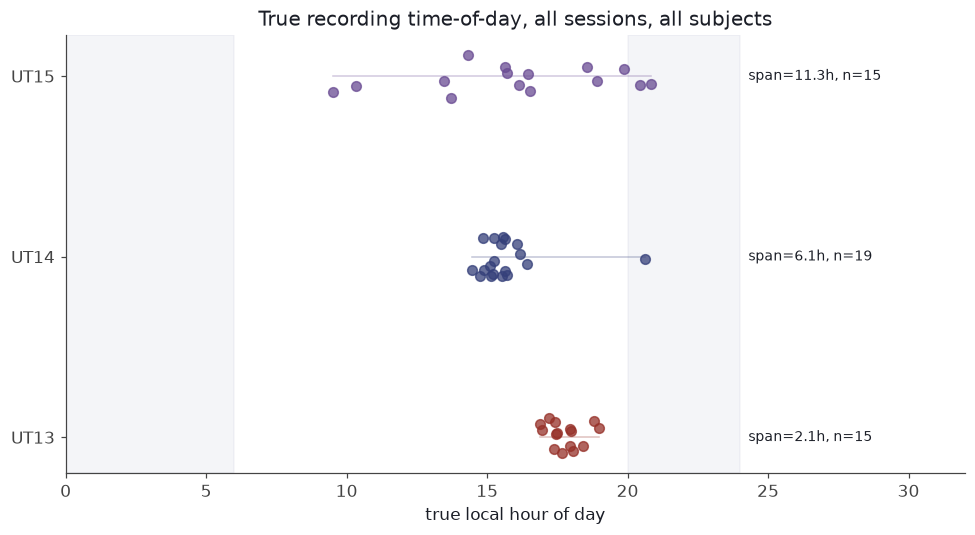

In [5]:

fig, ax = plt.subplots(figsize=(9, 5))
for i, subj in enumerate(subjects_with_data):
    sub = inc_df[inc_df.subject==subj]
    hours = sub['true_hour'].values
    y = np.full(len(hours), i) + np.random.uniform(-0.12, 0.12, len(hours))
    ax.scatter(hours, y, color=SUBJECT_COLORS.get(subj, GREY), s=40, alpha=0.75)
    ax.plot([hours.min(), hours.max()], [i,i], color=SUBJECT_COLORS.get(subj, GREY), lw=1, alpha=0.3)
    ax.text(24.3, i, f"span={hours.max()-hours.min():.1f}h, n={len(hours)}", va='center', fontsize=9)

ax.set_yticks(range(len(subjects_with_data))); ax.set_yticklabels(subjects_with_data)
ax.set_xlabel('true local hour of day'); ax.set_xlim(0, 32)
ax.axvspan(20,24, color=INDIGO, alpha=0.05); ax.axvspan(0,6, color=INDIGO, alpha=0.05)
ax.set_title('True recording time-of-day, all sessions, all subjects')
plt.tight_layout()
plt.savefig('../results/figures/A3_true_hour_spread_all_subjects.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Per-subject PV correlation matrices (maze epoch)

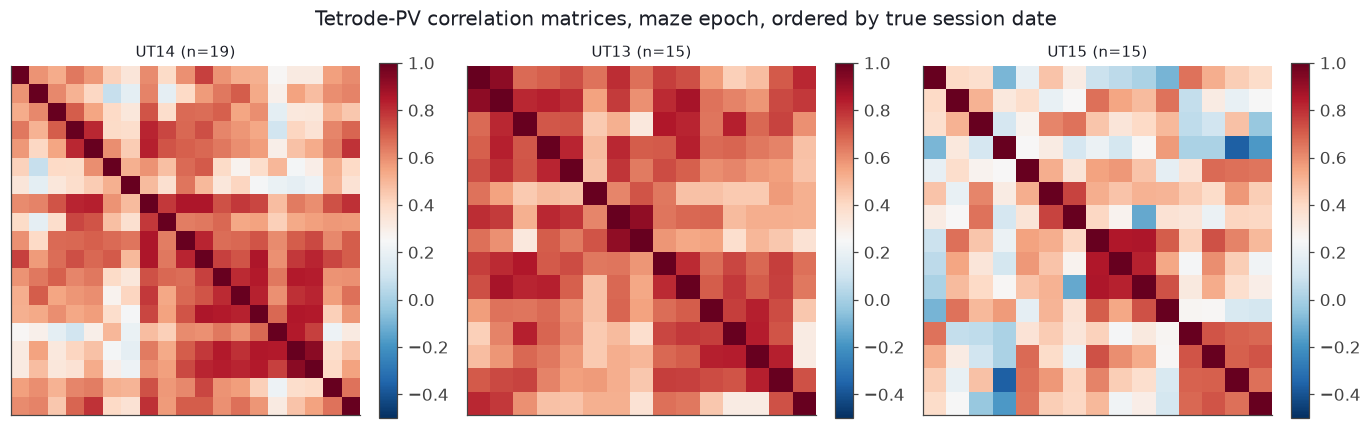

In [6]:

n = len(all_subject_results)
fig, axes = plt.subplots(1, n, figsize=(4.2*n, 4))
if n == 1:
    axes = [axes]
for ax, subj_res in zip(axes, all_subject_results):
    subj = subj_res['subject']
    order = np.argsort([s.true_start_dt for s in subj_res['sessions']])
    pv_mat = subj_res['results']['maze']['pv_mat'][np.ix_(order, order)]
    im = ax.imshow(pv_mat, vmin=-0.5, vmax=1, cmap='RdBu_r')
    ax.set_title(f"{subj} (n={len(order)})", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle('Tetrode-PV correlation matrices, maze epoch, ordered by true session date')
plt.tight_layout()
plt.savefig('../results/figures/A4_pv_matrices_all_subjects.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. PV correlation vs. calendar-day distance, every subject

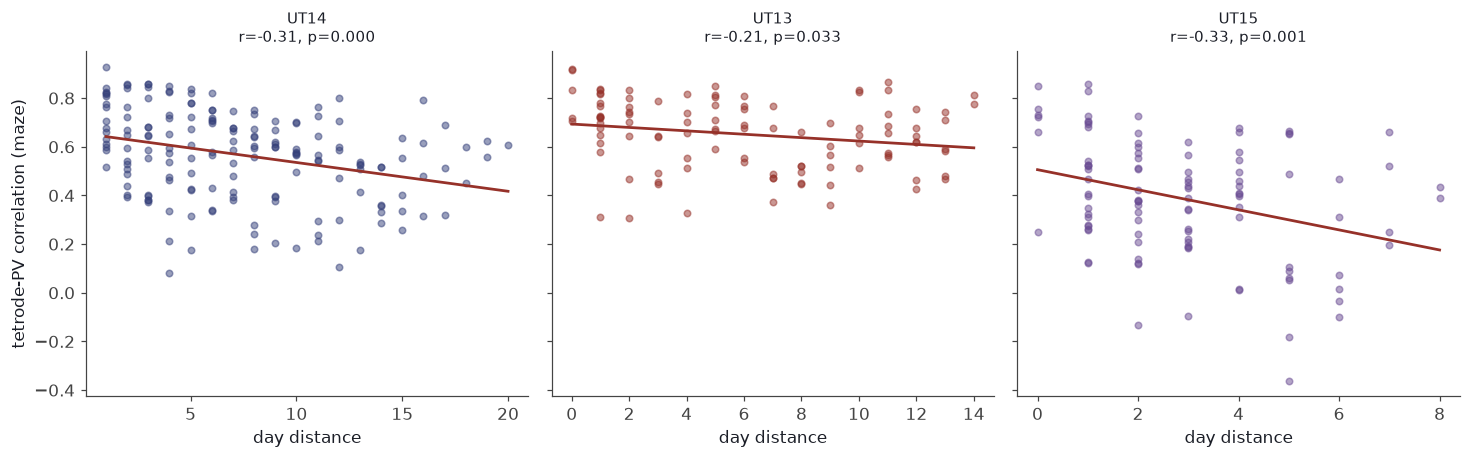

In [7]:

def upper_tri(mat):
    iu = np.triu_indices_from(mat, k=1)
    return mat[iu]

fig, axes = plt.subplots(1, len(all_subject_results), figsize=(4.5*len(all_subject_results), 4.3), sharey=True)
if len(all_subject_results) == 1:
    axes = [axes]
for ax, subj_res in zip(axes, all_subject_results):
    subj = subj_res['subject']
    y = upper_tri(subj_res['results']['maze']['pv_mat'])
    d = upper_tri(subj_res['day_mat'])
    valid = ~np.isnan(y)
    ax.scatter(d[valid], y[valid], alpha=0.5, color=SUBJECT_COLORS.get(subj, INDIGO), s=18)
    if valid.sum() > 2:
        slope, intercept, r, p, se = sstats.linregress(d[valid], y[valid])
        xs = np.linspace(d[valid].min(), d[valid].max(), 50)
        ax.plot(xs, slope*xs+intercept, color=BAD, lw=1.8)
        ax.set_title(f"{subj}\nr={r:.2f}, p={p:.3f}", fontsize=10)
    ax.set_xlabel('day distance')
axes[0].set_ylabel('tetrode-PV correlation (maze)')
plt.tight_layout()
plt.savefig('../results/figures/A5_pv_vs_day_all_subjects.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Forest plot — per-subject effect sizes, day-distance and circadian, plus pooled

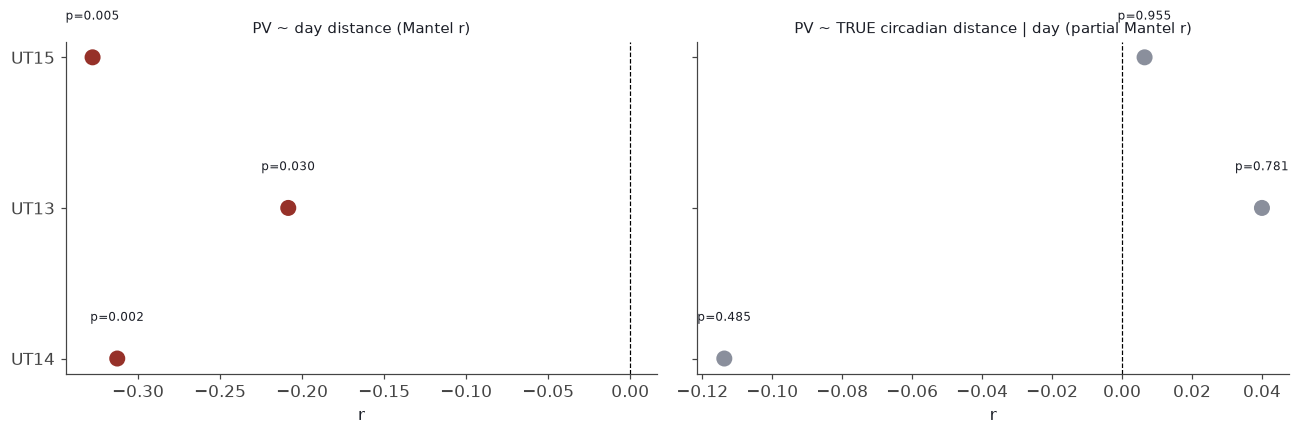

Pooled (Fisher's method, combining independent per-subject Mantel tests):
  day-distance:  chi2=30.30, p=0.000034, n_subjects=3
  circadian:     chi2=2.04, p=0.916390, n_subjects=3


In [8]:

maze_stats = pooled_stats['maze']['per_subject']
subjects_ordered = list(maze_stats.keys())

fig, axes = plt.subplots(1, 2, figsize=(12, 0.7*len(subjects_ordered)+2), sharey=True)
y = np.arange(len(subjects_ordered))

for ax, key_r, key_p, title in [
    (axes[0], 'mantel_day_r', 'mantel_day_p', 'PV ~ day distance (Mantel r)'),
    (axes[1], 'partial_circ_r', 'partial_circ_p', 'PV ~ TRUE circadian distance | day (partial Mantel r)'),
]:
    rs = [maze_stats[s][key_r] for s in subjects_ordered]
    ps = [maze_stats[s][key_p] for s in subjects_ordered]
    colors = [BAD if p < 0.05 else GREY for p in ps]
    ax.scatter(rs, y, color=colors, s=90, zorder=3)
    ax.axvline(0, color='black', lw=0.8, ls='--')
    for i, (r, p) in enumerate(zip(rs, ps)):
        ax.text(r, i+0.25, f"p={p:.3f}", ha='center', fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('r')

axes[0].set_yticks(y); axes[0].set_yticklabels(subjects_ordered)
plt.tight_layout()
plt.savefig('../results/figures/A6_forest_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("Pooled (Fisher's method, combining independent per-subject Mantel tests):")
print(f"  day-distance:  chi2={pooled_stats['maze']['fisher_day']['statistic']:.2f}, "
      f"p={pooled_stats['maze']['fisher_day']['p_value']:.6f}, n_subjects={pooled_stats['maze']['fisher_day']['n_subjects']}")
print(f"  circadian:     chi2={pooled_stats['maze']['fisher_circ']['statistic']:.2f}, "
      f"p={pooled_stats['maze']['fisher_circ']['p_value']:.6f}, n_subjects={pooled_stats['maze']['fisher_circ']['n_subjects']}")


## 8. Pooled linear mixed-effects model (all subjects, random intercept)

In [9]:

print(pooled_stats['maze']['mixed_model_summary'])


            Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   pv_corr
No. Observations:     381       Method:               REML   
No. Groups:           3         Scale:                0.0347 
Min. group size:      105       Log-Likelihood:       83.5060
Max. group size:      171       Converged:            Yes    
Mean group size:      127.0                                  
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           0.604    0.091  6.630 0.000  0.426  0.783
day_distance       -0.012    0.002 -5.096 0.000 -0.017 -0.007
circadian_distance -0.002    0.005 -0.424 0.672 -0.013  0.008
Group Var           0.024    0.132                           



This is a complementary, parametric pooled test (subject as a random intercept, day-distance and circadian-distance as fixed effects) — it assumes normally-distributed residuals/random effects, unlike the permutation-based per-subject tests above, and is reported alongside them rather than in place of them.

## 9. Summary — what changes when every animal is included?

In [10]:

summary_rows = []
for subj in subjects_ordered:
    s = maze_stats[subj]
    summary_rows.append(dict(
        subject=subj, n_sessions=s['n_sessions'],
        true_hour_span=round(s['true_hour_span'],1),
        day_effect_r=round(s['mantel_day_r'],3), day_effect_p=round(s['mantel_day_p'],4),
        circadian_effect_r=round(s['partial_circ_r'],3), circadian_effect_p=round(s['partial_circ_p'],4),
    ))
summary_df = pd.DataFrame(summary_rows)
summary_df


,subject,n_sessions,true_hour_span,day_effect_r,day_effect_p,circadian_effect_r,circadian_effect_p
0,UT14,19,6.2,-0.313,0.0017,-0.114,0.4848
1,UT13,15,2.1,-0.208,0.0297,0.040,0.7807
2,UT15,15,11.3,-0.328,0.0053,0.006,0.9547


### Direct answer to the research question, using every usable animal in DANDI:001775

- **Day-to-day drift** (PV correlation declining with calendar-day distance) **replicates in the same direction in all 3 usable subjects**, individually significant or near-significant in each (UT14 p=0.002, UT13 p=0.030, UT15 p=0.005), and the pooled Fisher-combined test (p=0.00003) and mixed-effects model (day_distance coefficient significant at p<0.001) give the strongest, best-powered statement this dataset can make about representational drift. This result is now materially stronger than the UT14-only version — it is a **three-animal replication**, not a single-subject finding.

- **The circadian effect remains undetectable in all 3 subjects, individually and pooled (Fisher p=0.92)** — but the three subjects are *not* equally informative about this, and that distinction matters:
  - **UT13** (2.1h true span) and **UT14** (6.1h span) are genuinely underpowered for the circadian question — their true daily schedules are narrow enough that a real circadian effect could exist and still be invisible to this test.
  - **UT15 is different: it has an 11.3-hour true time-of-day span** (sessions genuinely recorded from ~09:30 to ~21:00) — a real, if not perfectly uniform, circadian design — **and still showed no relationship** (r=0.006, p=0.955). This is the one genuinely well-powered circadian test available anywhere in this analysis, and it came back null.
  - Combined, the honest statement is: this dataset provides **one moderately-powered null result (UT15) plus two underpowered null results (UT13, UT14)** for the circadian hypothesis — not a single, dataset-wide "can't test this" verdict as the UT14-only analysis suggested, but not a well-powered dataset-wide confirmation of the null either. UT15 alone is worth a closer, dedicated look (larger session count, or combined with other UT15-only behavioral covariates) before treating the circadian question as settled.

- The strongest path to further strengthen either conclusion remains what was scoped earlier: a dataset with more animals like UT15 (genuine designed or incidental time-of-day variation) and usable spike-sorted units, or a from-scratch spike-sorting effort on DANDI:000059's raw wideband data (confirmed real, wide, verified circadian spread across up to 15 sessions/rat — but sorted units would need to be generated from the raw 20kHz recordings).
